In [40]:
from langchain_core.callbacks import UsageMetadataCallbackHandler

# Initialize the model with streaming enabled
llm = ChatOpenAI(
    model="gpt-4o",       # or any supported model
    temperature=0,
    streaming=True        # Enable streaming
)

# Input message
messages = [HumanMessage(content="How old was the 30th president of the United States when he died?")]
callback = UsageMetadataCallbackHandler()

# Stream response
final_response = ""
print("Streaming response:\n")
for chunk in llm.stream(messages, config={"callbacks": [callback]}):
    if chunk.content: 
        print(chunk.content, end="", flush=True)
        final_response += chunk.content

print(callback)
print(final_response)

Streaming response:

The 30th president of the United States was Calvin Coolidge. He was born on July 4, 1872, and died on January 5, 1933. This means he was 60 years old when he died.{'gpt-4o-2024-08-06': {'input_tokens': 23, 'output_tokens': 49, 'total_tokens': 72, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}}
The 30th president of the United States was Calvin Coolidge. He was born on July 4, 1872, and died on January 5, 1933. This means he was 60 years old when he died.


In [42]:
callback, callback.usage_metadata

({'gpt-4o-2024-08-06': {'input_tokens': 23, 'output_tokens': 49, 'total_tokens': 72, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}},
 {'gpt-4o-2024-08-06': {'input_tokens': 23,
   'output_tokens': 49,
   'total_tokens': 72,
   'input_token_details': {'audio': 0, 'cache_read': 0},
   'output_token_details': {'audio': 0, 'reasoning': 0}}})

In [44]:
from langchain.chat_models import init_chat_model
from langchain_core.callbacks import get_usage_metadata_callback

model_1 = init_chat_model(model="gpt-4o-mini")
model_2 = init_chat_model(model="gpt-4o")

with get_usage_metadata_callback() as cb:
    model_1.invoke("Hello")
    model_2.invoke("Hello")
    print(cb.usage_metadata)

{'gpt-4o-mini-2024-07-18': {'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'gpt-4o-2024-08-06': {'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}}


In [2]:
from typing import Literal
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from typing import Annotated, TypedDict
from langchain_core.messages import (AIMessage,
                                    BaseMessage,
                                    HumanMessage,
                                    SystemMessage,
                                    )
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

In [6]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [8]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [9]:
generate_prompt = SystemMessage(
 """You are an essay assistant tasked with writing excellent 3-paragraph 
        essays."""
 "Generate the best essay possible for the user's request."
 """If the user provides critique, respond with a revised version of your 
        previous attempts."""
)

In [10]:
generate_prompt

SystemMessage(content="You are an essay assistant tasked with writing excellent 3-paragraph \n        essays.Generate the best essay possible for the user's request.If the user provides critique, respond with a revised version of your \n        previous attempts.", additional_kwargs={}, response_metadata={})

In [11]:
def generate(state: State) -> State:
    answer = model.invoke([generate_prompt] + state["messages"])
    return {"messages": [answer]}

In [12]:
reflection_prompt = SystemMessage(
"""You are a teacher grading an essay submission. Generate critique and 
    recommendations for the user's submission."""
"""Provide detailed recommendations, including requests for length, depth, 
    style, etc."""
)

In [14]:
def reflect(state: State) -> State:
    # Invert the messages to get the LLM to reflect on its own output
    cls_map = {AIMessage: HumanMessage, HumanMessage: AIMessage}
    # First message is the original user request. 
    # We hold it the same for all nodes
    translated = [reflection_prompt, state["messages"][0]] + [cls_map[msg.__class__](content=msg.content) for msg in state["messages"][1:]]
    answer = model.invoke(translated)
    # We treat the output of this as human feedback for the generator
    return {"messages": [HumanMessage(content=answer.content)]}

In [17]:
def should_continue(state: State):
    if len(state["messages"]) > 6:
    # End after 3 iterations, each with 2 messages
        return END
    else:
        return "reflect"

In [18]:
builder = StateGraph(State)
builder.add_node("generate", generate)
builder.add_node("reflect", reflect)
builder.add_edge(START, "generate")
builder.add_conditional_edges("generate", should_continue)
builder.add_edge("reflect", "generate")

In [19]:
graph = builder.compile()

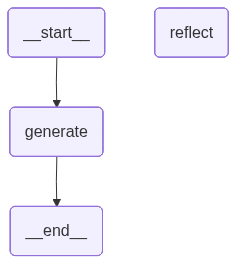

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
class SupervisorDecision(BaseModel):
     next: Literal["researcher", "coder", "FINISH"]
    
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
model = model.with_structured_output(SupervisorDecision)

agents = ["researcher", "coder"]

system_prompt_part_1 = f"""You are a supervisor tasked with managing a 
conversation between the following workers: {agents}. Given the following user 
request, respond with the worker to act next. Each worker will perform a
 task and respond with their results and status. When finished,
 respond with FINISH."""

system_prompt_part_2 = f"""Given the conversation above, who should act next? Or 
    should we FINISH? Select one of: {', '.join(agents)}, FINISH"""

def supervisor(state):
    messages = [
        ("system", system_prompt_part_1),
        *state["messages"],
        ("system", system_prompt_part_2)
        ]
    return model.invoke(messages)